In [1]:
import pandas as pd
import bson
import uuid
import numpy as np
import re
from scipy import stats as st
from statsmodels.stats.multitest import multipletests
import pingouin as pg
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
participants = pd.read_csv("../ueq/participants.csv", encoding="UTF-8", delimiter=";")
with open("../database/info.bson", "rb") as f:
    user_info = bson.decode_all(f.read())

In [3]:
df_participants_clean = participants[['ID', 'uid', 'Group']].rename(
    columns={
        'ID': 'pid',
        'Group': 'group'
    }
)

# standardize uids
df_participants_clean['uid'] = df_participants_clean['uid'].astype(str).str.strip().str.lower()
df_participants_clean

,pid,uid,group
0,1,3d3fad0c-f4e2-491f-97b3-95c71b7c6723,control_first
1,2,700afe5f-e6dc-4191-9ffc-2d540d21780d,experiment_first
2,3,071b323f-15a1-4f26-8510-9a857540cf04,experiment_first
3,4,ecd6e48c-d160-4ad1-b576-772aee78a77a,control_first
4,5,f21ef8da-e2e6-4a07-b757-2c2b8caa13df,experiment_first
5,6,2dbd9cc6-7d1f-4b50-9dc4-f22ba6c4aa09,control_first
6,7,4ddbf84b-633f-49e1-9412-e52629d7eb1e,experiment_first
7,8,28ea6a5b-7ea9-41b2-851c-1317b0df0019,experiment_first
8,9,05e5bd34-f2d8-4a3d-9453-e9f413cdfcf7,control_first
9,10,cd83ed7e-57d0-4ec5-8210-5acbbe5accae,control_first


In [4]:
femaleVoiceName = "Aoede"
femaleVoiceCount = 0

# calculate how many people selected a female voice
for info in user_info: 
    if "partner" in info.keys() and info["partner"]["voiceConfig"]["voiceName"] == femaleVoiceName:
        femaleVoiceCount += 1

femaleVoiceCount


15

In [5]:
# first we filter out all chats that don't belong to a valid participant account
def filter_user_info(_user_info: list[dict[str, any]]):
    valid_user_info = []

    for info in _user_info:
        uid = info.get("uid")

        # select only the chats from valid uids
        # ignore warmup chat
        if uid in participants["uid"].values:
            info["_id"] = str(info.get("_id"))
            valid_user_info.append({
                "uid": info["uid"],
                "language": info["language"]["code"],
                "level": info["level"]["code"],
                # noticed that if users used the default age range (26-29), it was not added as a field
                # so we pass each object that has no ageRange field the default age range
                "ageRange": info["ageRange"] if info.get("ageRange") else "26-29",
                "mothertongue": info["mothertongue"]["code"],
                "interests": info["interests"],
                "difficulties": info["difficulties"],
                "gender": info["gender"],
                "fieldOfWork": info["fieldOfWork"],
                "spokenLanguages": info["spokenLanguages"],
                "learningGoal": info["learningGoal"],
                "learningTools": info["learningTools"],
            })
            print(f"uid {uid} is in participants list.")

        else: 
            continue

    valid_user_info_len = len(valid_user_info)
    print(f"{valid_user_info_len} valid user infos found.\
          {"User info length is VALID" if valid_user_info_len == 40 else "User info length is INVALID"}")

    return valid_user_info

filtered_user_info = filter_user_info(user_info)
df_demographics = pd.DataFrame(filtered_user_info)
df_demographics.drop_duplicates("uid", inplace=True)
# save raw demographics data to clean them in Excel
# df_demographics.to_csv("./demographics.csv", encoding="UTF-8", delimiter=";")

uid 3d3fad0c-f4e2-491f-97b3-95c71b7c6723 is in participants list.
uid 700afe5f-e6dc-4191-9ffc-2d540d21780d is in participants list.
uid 071b323f-15a1-4f26-8510-9a857540cf04 is in participants list.
uid ecd6e48c-d160-4ad1-b576-772aee78a77a is in participants list.
uid f21ef8da-e2e6-4a07-b757-2c2b8caa13df is in participants list.
uid 2dbd9cc6-7d1f-4b50-9dc4-f22ba6c4aa09 is in participants list.
uid 4ddbf84b-633f-49e1-9412-e52629d7eb1e is in participants list.
uid 28ea6a5b-7ea9-41b2-851c-1317b0df0019 is in participants list.
uid 05e5bd34-f2d8-4a3d-9453-e9f413cdfcf7 is in participants list.
uid cd83ed7e-57d0-4ec5-8210-5acbbe5accae is in participants list.
uid af32f0e9-f534-424a-9273-029dd49ac79f is in participants list.
uid 71a109a5-6e81-44b3-b77f-531237e1c7d2 is in participants list.
uid 1102ec51-1323-4617-bb60-7fe36ea9f85d is in participants list.
uid a8ca69a9-9e73-47df-be37-9dab3392595d is in participants list.
uid 27f0896f-c214-4a26-9e54-4e19d62bec64 is in participants list.
uid 27f089

In [31]:
filtered_user_info[20]

{'_id': '6a38092cf797bba0c623ff68',
 'name': 'Ilayda',
 'language': {'code': 'es', 'name': 'spanish'},
 'level': {'name': 'beginner', 'code': 'a1'},
 'mothertongue': {'code': 'de', 'name': 'German'},
 'difficulties': ['Vocabulary',
  'Fear of Speaking',
  'Grammar Rules',
  'Sentence Structure',
  'Listening Comprehension'],
 'interests': ['Travel', 'Food & Cooking', 'Movies & TV'],
 'gender': 'female',
 'fieldOfWork': 'Educational Scientist',
 'spokenLanguages': ['English', 'Turkish', 'Dutch'],
 'learningGoal': 'I want to trust myself more to speak in public and I want to have at least B2.',
 'learningTools': ['Duolingo', 'Music'],
 'uid': '029df5a6-c0ca-41d9-8c3f-da05543cef44',
 'partner': {'name': 'Zeyto Abi',
  'voiceConfig': {'voiceName': 'Charon', 'languageCode': 'en-US'},
  'personalityDescription': '',
  'color': 'skin-light',
  'hair': 'hair-medium',
  'eyes': 'eyes-round',
  'nose': 'nose-curve',
  'mouth': 'mouth-neutral'}}

### Cleaned data
After the data was cleaned in Excel, it can be processed.

In [6]:
# Make sure all columns are capitalized
df_demographics = pd.read_csv("./cleaned_demographics.csv", encoding="UTF-8", delimiter=";")
df_demographics


,uid,language,level,ageRange,mothertongue,interests,difficulties,gender,fieldOfWork,spokenLanguages,learningGoal,learningTools
0,3d3fad0c-f4e2-491f-97b3-95c71b7c6723,es,a1,26-29,de,"['Food & Cooking', 'Technology', 'Music', 'Tra...","['Gendered Nouns', 'Grammar Rules', 'Idioms & ...",male,Software Engineering,"['English', 'French']",- establish a solid basis in conversation\r\n-...,"['Other language apps', 'Music', 'Videos']"
1,700afe5f-e6dc-4191-9ffc-2d540d21780d,es,a1,22-25,de,"['Music', 'History', 'Science', 'Gaming', 'Boo...","['Fear of Speaking', 'Vocabulary']",male,Student,"['English', 'French', 'Dutch']",I want to be able to speak fluently in my next...,"['Duolingo', 'Other language apps', 'Videos', ..."
2,071b323f-15a1-4f26-8510-9a857540cf04,es,a2,22-25,de,"['Music', 'Sports', 'Food & Cooking', 'Fashion']","['Vocabulary', 'Pronunciation', 'Sentence Stru...",female,Teacher,"['English', 'Spanish', 'French']",I want to feel comfortable when speaking becau...,['Classes']
3,ecd6e48c-d160-4ad1-b576-772aee78a77a,es,a1,22-25,dari,"['Travel', 'Music', 'Movies & TV', 'Nature', '...","['Fear of Speaking', 'Gendered Nouns', 'Idioms...",female,Student,"['English', 'German']",I want to speak fluently in spanish whenever I...,"['Duolingo', 'Music']"
4,f21ef8da-e2e6-4a07-b757-2c2b8caa13df,es,a1,22-25,de,"['Food & Cooking', 'Travel', 'Music', 'Sports'...","['Vocabulary', 'Verb Conjugations', 'Sentence ...",female,Student,"['English', 'French']","In some ideal future, I want to move back to M...","['Duolingo', 'Other language apps', 'Videos']"
5,2dbd9cc6-7d1f-4b50-9dc4-f22ba6c4aa09,es,a2,34-37,de,"['Music', 'Technology', 'Business', 'Nature', ...","['Vocabulary', 'Verb Conjugations', 'Grammar R...",male,Production Engineering,"['Spanish', 'English', 'Portuguese']",I want to have simple conversations in spanish,"['Classes', 'Duolingo', 'Videos', 'Peliculas']"
6,4ddbf84b-633f-49e1-9412-e52629d7eb1e,es,a1,26-29,de,"['Music', 'Food & Cooking', 'Gaming', 'Movies ...","['Vocabulary', 'Verb Conjugations', 'Fear of S...",female,Student,['Polish'],Zu testen wie weit mein Spanisch noch funktion...,"['Duolingo', 'Classes']"
7,28ea6a5b-7ea9-41b2-851c-1317b0df0019,es,a1,26-29,de,"['Travel', 'Music', 'Sports', 'Science', 'Hist...","['Idioms & Expressions', 'Grammar Rules', 'Voc...",male,Consulting,"['Arabic', 'Mandarin Chinese', 'English', 'Fre...",Become fluent in Spanish,"['Duolingo', 'Classes', 'Videos', 'Music', 'Te..."
8,05e5bd34-f2d8-4a3d-9453-e9f413cdfcf7,es,a2,18-21,de,"['Music', 'History', 'Science', 'Gaming', 'Tec...","['Vocabulary', 'Verb Conjugations', 'Idioms & ...",male,Student,"['Spanish', 'English']",I want to be able to fluently speak Spanish in...,['Duolingo']
9,cd83ed7e-57d0-4ec5-8210-5acbbe5accae,es,a1,26-29,de,"['Music', 'Movies & TV', 'Nature', 'Gaming', '...","['Vocabulary', 'Grammar Rules', 'Pronunciation']",male,Educational Science,"['English', 'Norwegian']",Gespräche im Alltag souverän führen können.,"['Duolingo', 'Videos']"


In [7]:
%pip install Jinja2
# capitalize all relevant columns
df_table = pd.DataFrame()
df_table["level"] = df_demographics["level"].str.upper()
df_table["fieldOfWork"] = df_demographics["fieldOfWork"]
df_table["motherTongue"] = df_demographics["mothertongue"].replace({
    "de": "German",
    "dari": "Dari",
    "albanian": "Albanian"
})
df_table["gender"] = df_demographics["gender"].replace({
    "female": "F",
    "male": "M"
})
df_table["spokenLanguages"] = (
    df_demographics["spokenLanguages"]
    .astype(str)
    .str.strip("[]")
    .str.replace("'", "")
    .str.replace('"', "")
)

df_table["ageRange"] = df_demographics["ageRange"]

df_table["learningTools"] = (
    df_demographics["learningTools"]
    .astype(str)
    .str.strip("[]")
    .str.replace("'", "")
    .str.replace('"', "")
)
df_table["ID"] = df_demographics.index + 1
df_table

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


,level,fieldOfWork,motherTongue,gender,spokenLanguages,ageRange,learningTools,ID
0,A1,Software Engineering,German,M,"English, French",26-29,"Other language apps, Music, Videos",1
1,A1,Student,German,M,"English, French, Dutch",22-25,"Duolingo, Other language apps, Videos, Classes",2
2,A2,Teacher,German,F,"English, Spanish, French",22-25,Classes,3
3,A1,Student,Dari,F,"English, German",22-25,"Duolingo, Music",4
4,A1,Student,German,F,"English, French",22-25,"Duolingo, Other language apps, Videos",5
5,A2,Production Engineering,German,M,"Spanish, English, Portuguese",34-37,"Classes, Duolingo, Videos, Peliculas",6
6,A1,Student,German,F,Polish,26-29,"Duolingo, Classes",7
7,A1,Consulting,German,M,"Arabic, Mandarin Chinese, English, French, Spa...",26-29,"Duolingo, Classes, Videos, Music, Texts",8
8,A2,Student,German,M,"Spanish, English",18-21,Duolingo,9
9,A1,Educational Science,German,M,"English, Norwegian",26-29,"Duolingo, Videos",10


In [99]:
# export the participant table as latex
print(df_table[["ID", "ageRange", "fieldOfWork", "motherTongue", "level", "gender"]].to_latex(index=False))

\begin{tabular}{rlllll}
\toprule
ID & ageRange & fieldOfWork & motherTongue & level & gender \\
\midrule
1 & 26-29 & Software Engineering & German & A1 & M \\
2 & 22-25 & Student & German & A1 & M \\
3 & 22-25 & Teacher & German & A2 & F \\
4 & 22-25 & Student & Dari & A1 & F \\
5 & 22-25 & Student & German & A1 & F \\
6 & 34-37 & Production Engineering & German & A2 & M \\
7 & 26-29 & Student & German & A1 & F \\
8 & 26-29 & Consulting & German & A1 & M \\
9 & 18-21 & Student & German & B1 & M \\
10 & 26-29 & Educational Science & German & A1 & M \\
11 & 26-29 & Data Science & German & A2 & M \\
12 & 30-33 & Law & German & A1 & F \\
13 & 30-33 & Police Officer & German & A1 & M \\
14 & 18-21 & Student & German & A2 & F \\
15 & 30-33 & Student & German & A1 & M \\
16 & 34-37 & Credit Advisor & German & B1 & F \\
17 & 26-29 & Student & Albanian & A1 & F \\
18 & 22-25 & Student & German & A1 & F \\
19 & 26-29 & Student & German & A1 & M \\
20 & 26-29 & Educational Science & German & A1 &

In [4]:
spokenLanguages = {}

for key, value in df_demographics["spokenLanguages"].items():
    
    for lang in value:
        if spokenLanguages.get(lang): 
            spokenLanguages[lang] += 1

        else: 
            spokenLanguages[lang] = 1

spokenLanguages

{'English': 19,
 'French': 7,
 'Dutch': 3,
 'Spanish': 8,
 'German': 2,
 'Portuguese': 2,
 'Polish': 1,
 'Arabic': 1,
 'Mandarin Chinese': 1,
 'Norwegian': 1,
 'Albanian': 1,
 'Turkish': 2,
 'Latin': 1}

In [65]:
tools = {}

for key, value in df_demographics["learningTools"].items():
    
    for tool in value:
        if tools.get(tool): 
            tools[tool] += 1

        else: 
            tools[tool] = 1

tools

{'Other language apps': 4,
 'Music': 7,
 'Videos': 9,
 'Duolingo': 13,
 'abblino': 1,
 'babbel': 1,
 'Classes': 9,
 'Peliculas': 1,
 'Texts': 2,
 'Movies': 1,
 'Watch netflix': 1}

In [67]:
diffs = {}

for key, value in df_demographics["difficulties"].items():
    
    for d in value:
        if diffs.get(d): 
            diffs[d] += 1

        else: 
            diffs[d] = 1

diffs

{'Gendered Nouns': 4,
 'Grammar Rules': 11,
 'Idioms & Expressions': 7,
 'Sentence Structure': 6,
 'Verb Conjugations': 11,
 'Fear of Speaking': 7,
 'Vocabulary': 14,
 'Pronunciation': 4,
 'Listening Comprehension': 8}

C:\Users\mmmue\AppData\Local\Temp\ipykernel_39200\1261138036.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, ax=axes[i], palette=kit_palette_std)
C:\Users\mmmue\AppData\Local\Temp\ipykernel_39200\1261138036.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=axes[i], palette=kit_palette_std, order=age_order)
C:\Users\mmmue\AppData\Local\Temp\ipykernel_39200\1261138036.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, ax=axes[i], pal

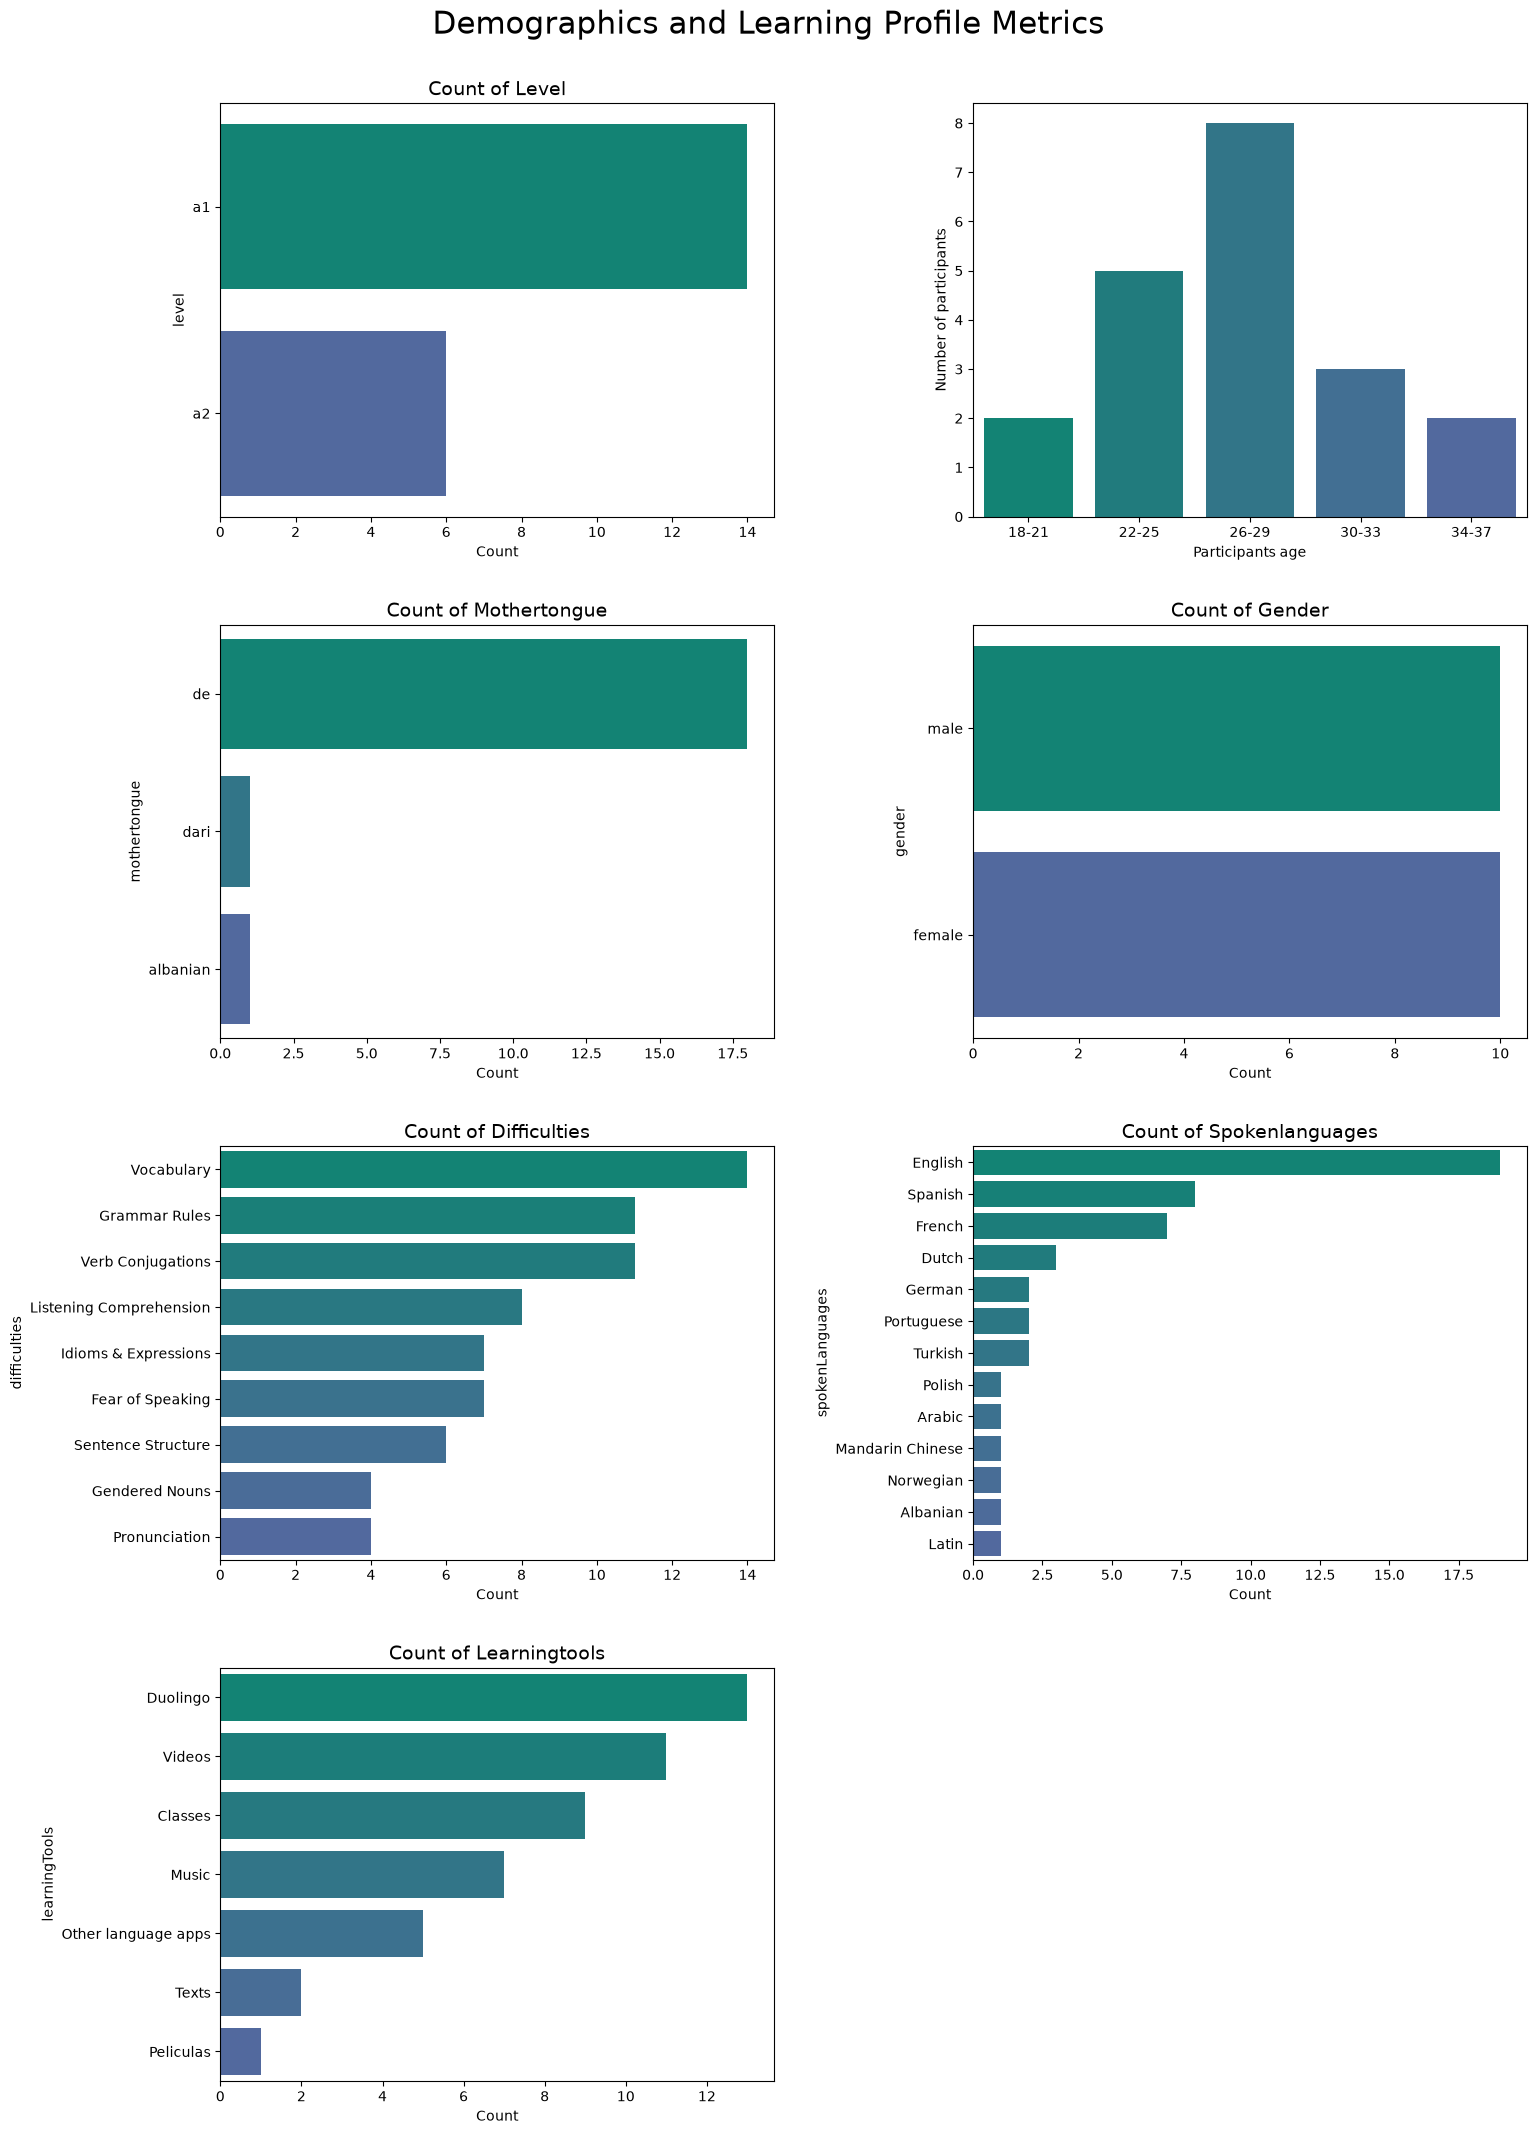

In [8]:
# Assuming your dataframe is already loaded as 'df'

def parse_lists(val):
    # 1. If it is already a list, just return it as-is!
    if isinstance(val, list):
        return val
    
    # 2. If it's a string, clean it and split it into a list
    if isinstance(val, str):
        val = val.strip('[]').strip()
        # If the string was empty or just "[]", return an empty list
        if not val:
            return []
        return [item.strip().strip("'\"") for item in val.split(',')]
    
    # 3. If it's anything else (like NaN, None, or a float), return an empty list
    return []

# Apply the parsing function to our list-like columns
list_cols = ['difficulties', 'spokenLanguages', 'learningTools']
for col in list_cols:
    df_demographics[col] = df_demographics[col].apply(parse_lists)

kit_green = '#009682'
kit_blue = '#4664AA'
kit_black = '#404040'

# 2. Define our metrics
standard_metrics = ['level', 'ageRange', 'mothertongue', 'gender']
list_metrics = ['difficulties', 'spokenLanguages', 'learningTools']

# 3. Setup the Matplotlib figure (4 rows, 2 columns)
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 22))
fig.suptitle('Demographics and Learning Profile Metrics', fontsize=22, y=0.98)
axes = axes.flatten() # Flatten the 4x2 array to easily iterate over it

age_order = ["18-21", "22-25", "26-29", "30-33", "34-37"]

# 4. Plot the Standard Metrics
for i, col in enumerate(standard_metrics):
    # Simply count the values
    counts = df_demographics[col].value_counts()
    kit_palette_std = sns.blend_palette([kit_green, kit_blue], n_colors=len(counts))

    if col == 'ageRange':
        # Create palette based on the number of categories in our custom order
        kit_palette_std = sns.blend_palette([kit_green, kit_blue], n_colors=len(age_order))
        

        sns.barplot(x=counts.index, y=counts.values, ax=axes[i], palette=kit_palette_std, order=age_order)
        axes[i].set_xlabel('Participants age')
        axes[i].set_ylabel('Number of participants')

    else: 
        sns.barplot(x=counts.values, y=counts.index, ax=axes[i], palette=kit_palette_std)
        axes[i].set_title(f'Count of {col.capitalize()}', fontsize=14)
        axes[i].set_xlabel('Count')
        axes[i].set_ylabel(col)

# 5. Plot the List Metrics
for i, col in enumerate(list_metrics):
    # Use .explode() to split the lists into separate rows before counting
    counts = df_demographics.explode(col)[col].value_counts()

    
    kit_palette_std = sns.blend_palette([kit_green, kit_blue], n_colors=len(counts))
    sns.barplot(x=counts.values, y=counts.index, ax=axes[i+4], palette=kit_palette_std)
    axes[i+4].set_title(f'Count of {col.capitalize()}', fontsize=14)
    axes[i+4].set_xlabel('Count')
    axes[i+4].set_ylabel(col)

# 6. Clean up the layout and display
fig.delaxes(axes[7]) # Remove the 8th empty subplot (since we only have 7 metrics)
plt.tight_layout(pad=3.0)
plt.show()

In [9]:
def parse_lists(val):
    # 1. If it is already a list, just return it as-is!
    if isinstance(val, list):
        return val
    
    # 2. If it's a string, clean it and split it into a list
    if isinstance(val, str):
        val = val.strip('[]').strip()
        # If the string was empty or just "[]", return an empty list
        if not val:
            return []
        return [item.strip().strip("'\"") for item in val.split(',')]
    
    # 3. If it's anything else (like NaN, None, or a float), return an empty list
    return []

# Apply the parsing function to our list-like columns
list_cols = ['difficulties', 'spokenLanguages', 'learningTools']
for col in list_cols:
    df_demographics[col] = df_demographics[col].apply(parse_lists)

kit_green = '#009682'
kit_blue = '#4664AA'
kit_black = '#404040'

# Define our metrics
standard_metrics = ['level', 'ageRange', 'mothertongue', 'gender']
list_metrics = ['difficulties', 'spokenLanguages', 'learningTools']

# Dictionary for nice labels and filenames
pretty_names = {
    'level': 'Level',
    'ageRange': 'Age Range',
    'mothertongue': 'Mother Tongue',
    'gender': 'Gender',
    'difficulties': 'Difficulties',
    'spokenLanguages': 'Spoken Languages',
    'learningTools': 'Learning Tools'
}

age_order = ["18-21", "22-25", "26-29", "30-33", "34-37"]

# 1. Plot and save the Standard Metrics
for col in standard_metrics:
    # Create a new figure for each plot
    plt.figure(figsize=(8, 6))
    
    counts = df_demographics[col].value_counts()
    pretty_col = pretty_names[col]

    if col == 'ageRange':
        # Create palette based on the number of categories in our custom order
        kit_palette_std = sns.blend_palette([kit_green, kit_blue], n_colors=len(age_order))
        ax = sns.barplot(x=counts.index, y=counts.values, palette=kit_palette_std, order=age_order)
        
        ax.set_title(f'Count of {pretty_col}', fontsize=14)
        ax.set_xlabel('Participants Age')
        ax.set_ylabel('Number of Participants')
    else: 
        kit_palette_std = sns.blend_palette([kit_green, kit_blue], n_colors=len(counts))
        ax = sns.barplot(x=counts.values, y=counts.index, palette=kit_palette_std)
        
        ax.set_title(f'Count of {pretty_col}', fontsize=14)
        ax.set_xlabel('Count')
        ax.set_ylabel(pretty_col)

    plt.tight_layout()
    # Save as PDF with a clean filename (e.g., 'Age_Range.pdf')
    file_name = f"{pretty_col.replace(' ', '_')}.pdf"
    plt.savefig(file_name, format='pdf', bbox_inches='tight')
    plt.close() # Close the figure to free up memory

# 2. Plot and save the List Metrics
for col in list_metrics:
    # Create a new figure for each plot
    plt.figure(figsize=(10, 6))
    
    # Use .explode() to split the lists into separate rows before counting
    counts = df_demographics.explode(col)[col].value_counts()
    pretty_col = pretty_names[col]
    
    kit_palette_std = sns.blend_palette([kit_green, kit_blue], n_colors=len(counts))
    ax = sns.barplot(x=counts.values, y=counts.index, palette=kit_palette_std)
    
    ax.set_title(f'Count of {pretty_col}', fontsize=14)
    ax.set_xlabel('Count')
    ax.set_ylabel(pretty_col)

    plt.tight_layout()
    # Save as PDF with a clean filename
    file_name = f"{pretty_col.replace(' ', '_')}.pdf"
    plt.savefig(file_name, format='pdf', bbox_inches='tight')
    plt.close() # Close the figure to free up memory

C:\Users\mmmue\AppData\Local\Temp\ipykernel_39200\2994884249.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.values, y=counts.index, palette=kit_palette_std)
C:\Users\mmmue\AppData\Local\Temp\ipykernel_39200\2994884249.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette=kit_palette_std, order=age_order)
C:\Users\mmmue\AppData\Local\Temp\ipykernel_39200\2994884249.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.values, y=counts.index, palette=kit_palette_std)

C:\Users\mmmue\AppData\Local\Temp\ipykernel_33120\4240682688.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette=kit_palette_list)


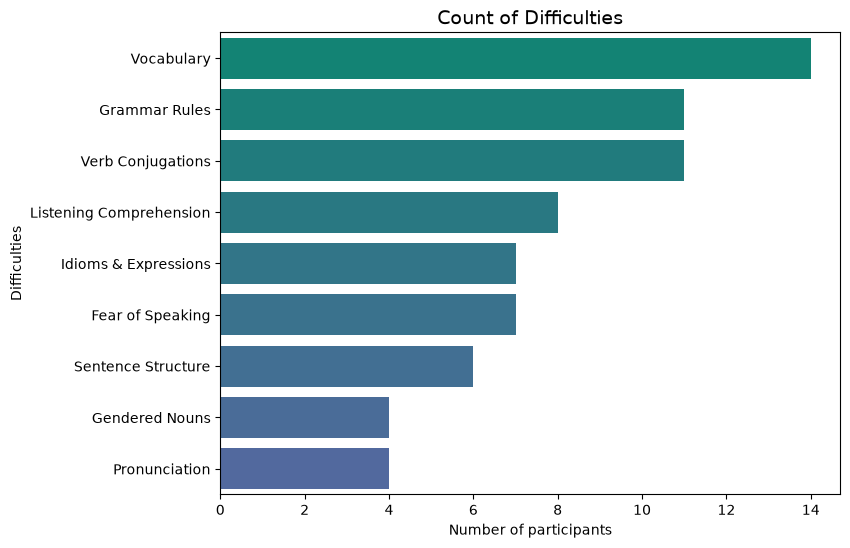

In [10]:

# 2. Get the counts for difficulties
# We use .explode() to split the lists into separate rows before counting
counts = df_demographics.explode('difficulties')['difficulties'].value_counts()

# 3. Create a new, standalone figure (adjust figsize as needed)
plt.figure(figsize=(8, 6))

# Create the gradient palette from Blue to Black
kit_palette_list = sns.blend_palette([kit_green, kit_blue], n_colors=len(counts))

# 4. Create the plot
sns.barplot(x=counts.values, y=counts.index, palette=kit_palette_list)

# 5. Add labels and title
plt.title('Count of Difficulties', fontsize=14)
plt.xlabel('Number of participants')
plt.ylabel('Difficulties')

# 6. Save as SVG BEFORE plt.show()
# bbox_inches='tight' prevents cut-off labels
plt.savefig('difficulties_plot.pdf', format='pdf', bbox_inches='tight')

# 7. Display the plot
plt.show()